# Dimension scoring for contextual encoding

Seppo Nyrkkö 2026

In [1]:
import databox as db

import scipy as sp
import numpy as np
import pandas as pd
import os
import re

# ###### reloading helper #####

import importlib
import extools as ex


from collections import defaultdict
t1_id = 'Com-b39d_2_basilisk-3'
t2_id = 'Com-b39d_25_basilisk-4'

ex.pretty_token(t1_id).t_synt.head(15).T



OK -- read the ontology db (19571, 4)
Restored 303734 tags and 191240 tokens. Run update_corpus_tagdata() to update.
-- loaded the skipgram model tank/fasttext_8.model --


widx,1,2,3,4,5,6,7,8,9,10,11,12,13
form,The,common,basilisk,(,Basiliscus,basiliscus,),is,a,species,of,lizard,in
arcpath,det>,amod>,,,appos>compound>,appos>,,nsubj<cop>,nsubj<det>,nsubj<,nsubj<nmod>case>,nsubj<nmod>,


## Usage examples of the "databox" module 

for accessing the data

The dimension tests will follow below.

In [2]:
tt = db.tag_df[db.tag_df.token_form=='waters'].token_id
tt

tag_id
Ame-fe9c_87_waters-24_4512      Ame-fe9c_87_waters-24
Anc-20c3_3_waters-7_4512          Anc-20c3_3_waters-7
Bas-63b2_36_waters-11_4512      Bas-63b2_36_waters-11
Bel-4321_301_waters-25_4512    Bel-4321_301_waters-25
Bra-fdd7_10_waters-8_4512        Bra-fdd7_10_waters-8
Bra9ff1_6_waters-13_4512          Bra9ff1_6_waters-13
Dug-bf37_96_waters-8_4512        Dug-bf37_96_waters-8
Fro-21e4_35_waters-9_4512        Fro-21e4_35_waters-9
Gob-6481_46_waters-14_4512      Gob-6481_46_waters-14
Nil-600c_393_waters-16_4512    Nil-600c_393_waters-16
Osp-8ead_96_waters-15_4512      Osp-8ead_96_waters-15
Pin-2f45_232_waters-26_4512    Pin-2f45_232_waters-26
Pin-2f45_232_waters-32_4512    Pin-2f45_232_waters-32
Name: token_id, dtype: object

In [3]:
([ttt+':'+' '.join(db.token_sent(ttt).form) for ttt in tt])

['Ame-fe9c_87_waters-24:Contrary to popular misinformation the presence of the American alligator is not the reason the American crocodile was unable to populate brackish waters north of Florida but rather the climate as crocodiles are less tolerant of cold',
 'Anc-20c3_3_waters-7:Most species are found in marine waters but several will enter brackish water and some in South America are restricted to fresh water',
 'Bas-63b2_36_waters-11:It lives around the continental shelf and occasionally enters brackish waters',
 'Bel-4321_301_waters-25:A few other individuals have been confirmed to return to the coasts of Hokkaido and one particular individual became a resident in brackish waters of Lake Notoro since in 2014',
 'Bra-fdd7_10_waters-8:It is characteristic of many brackish surface waters that their salinity can vary considerably over space or time',
 'Bra9ff1_6_waters-13:Since conditions are optimal for neither freshwater or marine creatures brackish waters often lack diversity',
 'D

In [4]:
ex.pretty_token(t2_id).t_synt.head(15).T


widx,1,2,3,4,5,6,7,8,9,10,11,12,13,14
form,Although,the,common,basilisk,stays,close,to,water,to,escape,terrestrial,predators,",",it
arcpath,nsubj<mark>,det>,amod>,,nsubj<,nsubj<xcomp>,,nsubj<xcomp>obl>,,nsubj<xcomp>advcl>,,,,


In [6]:
db.token_data(t2_id)

document      Common_basilisk-en-b39d
sent_id                            25
word_id                             4
token_form                   basilisk
Name: Com-b39d_25_basilisk-4, dtype: object

In [7]:
pd.concat([db.token_arcs(t2_id),db.token_arcs_ex_term(t2_id)],axis=1).fillna('')

,arcpath,lemma,upos,widx,arcpath,lemma,upos,widx
77,nsubj<mark>,although,SCONJ,1,nsubj<mark>,although,SCONJ,1.0
81,det>,the,DET,2,det>,the,DET,2.0
82,amod>,common,ADJ,3,,,,
76,nsubj<,stay,VERB,5,nsubj<,stay,VERB,5.0
78,nsubj<xcomp>,close,ADJ,6,nsubj<xcomp>,close,ADJ,6.0
79,nsubj<xcomp>obl>,water,NOUN,8,nsubj<xcomp>obl>,water,NOUN,8.0
80,nsubj<xcomp>advcl>,escape,VERB,10,nsubj<xcomp>advcl>,escape,VERB,10.0


In [8]:
a1_df = db.token_arcs_ex_term(t1_id)
a1_df

,arcpath,lemma,upos,widx
43,det>,the,DET,1
46,appos>compound>,Basiliscus,NOUN,5
45,appos>,basiliscus,NOUN,6
38,nsubj<cop>,be,AUX,8
39,nsubj<det>,a,DET,9
37,nsubj<,species,NOUN,10
41,nsubj<nmod>case>,of,ADP,11
40,nsubj<nmod>,lizard,NOUN,12
42,nsubj<nmod>nmod>,Corytophanidae,NOUN,16


In [9]:
a2_df = db.token_arcs_ex_term(t2_id)
a2_df

,arcpath,lemma,upos,widx
77,nsubj<mark>,although,SCONJ,1
81,det>,the,DET,2
76,nsubj<,stay,VERB,5
78,nsubj<xcomp>,close,ADJ,6
79,nsubj<xcomp>obl>,water,NOUN,8
80,nsubj<xcomp>advcl>,escape,VERB,10


# Dimension test

use Fibonacci series as try-outs

In [10]:
fib = lambda n: n if n < 2 else fib(n-1) + fib(n-2)
fibs = [fib(i) for i in range(3,11)]
print(fibs)

[2, 3, 5, 8, 13, 21, 34, 55]


In [11]:
cand_D = [int(2**i) for i in np.arange(4,8,.5)]+[256]
cand_D

[16, 22, 32, 45, 64, 90, 128, 181, 256]

*Select a few tokens for dimension testing*

In [10]:
#cand_tokens = db.tag_df.token_id.sample(50).unique()[0:20]
#pd.DataFrame(cand_tokens,columns=['token_id']).to_csv('dimension_exp_tokens.csv')
cand_tokens = pd.read_csv('dimension_exp_tokens.csv')['token_id']
cand_tokens

0     Afr-0045_170_elephants-11
1          Bel-4321_129_cones-6
2     Red-a286_103_squirrels-30
3      Wat-9861_153_buffaloes-5
4        Meg-fd01_213_mammals-3
5           Eur-ee4d_29_birds-9
6            Bar-4870_40_bird-5
7          Sno-0a8f_263_owls-13
8      Chi-c10a_17_chimpanzee-6
9       Com-3b7c_84_blackbird-4
10       Ani-161e_242_mammals-5
11           Com-f597_2_frog-32
12     Coc-65ef_185_Blattodea-2
13       Psi-37fd_10_parrots-12
14         Til-f451_75_plants-6
15       Nor-d13e_197_otters-33
16          Cob-d13e_5_cobras-6
17             Com-2ad3_4_bat-4
18        Hou-905b_116_birds-24
19     Sil-d352_124_Silphidae-1
Name: token_id, dtype: object

In [13]:
def comp_collisions(word_dim : int, input_dim : int, token_ids : list, debug = 0):

    db.set_D_wordvec(word_dim)
    db.D_input= input_dim
    
    summ_dfs = []


    a = dict()
    v = dict()

    for t in token_ids:
        a[t],v[t] = db.token_link_matrix(t,1)

    for i in token_ids:
        v1 = v[i].sum(axis=0)
        hits = pd.DataFrame([np.inner(v[i][x,:],v1) for x in range(v[i].shape[0])],
                                   index=a[i].arcpath+' '+a[i].lemma,
                                  columns=['hit_inn_prod']).round(2)
                
        if debug>0:
            print("\n"+i)
            print(hits.describe().head(3))
            
        if debug>1:
            print(hits)
            
        s = hits.describe().head(3).T
        
        summ_dfs.append(s)
            
        misses = []
        
        for j in token_ids:
            if i != j:
                
                v2 = v[j].sum(axis=0)
                df = pd.DataFrame(
                    [np.inner(v[i][x,:],v2) for x in range(v[i].shape[0])],
                                  index=a[i].arcpath+' '+a[i].lemma,
                                  columns=['miss_inn_prod']).round(2)
                
                misses.append(df)
                
        miss_df = pd.concat(misses,axis=0)
        if debug>0:
            print(miss_df.describe().head(3))
        if debug>1:
            print(pd.concat(misses,axis=1))

        summ_dfs.append(miss_df.describe().head(3).T)
    return pd.concat(summ_dfs)
        
        
        

In [14]:
 comp_collisions(5,24,cand_tokens[0:3],debug=2)

-- loaded the skipgram model tank/fasttext_5.model --

Afr-0045_170_elephants-11
       hit_inn_prod
count     15.000000
mean       1.205333
std        0.910901
                                 hit_inn_prod
nsubj:pass<ccomp<obl> 2006               2.36
nsubj:pass<ccomp<nsubj:pass> it          0.90
nsubj:pass<ccomp<aux:pass> be            0.36
nsubj:pass<ccomp< estimate               1.84
nsubj:pass<mark> that                   -0.10
nummod> 410                              2.19
compound>amod> african                   1.88
nsubj:pass<aux:pass> be                  0.73
nsubj:pass< kill                         2.30
nsubj:pass<advmod> yearly                0.94
nsubj:pass<obl>case> in                  1.40
nsubj:pass<obl>det> the                  1.57
nsubj:pass<obl>compound> Bioko          -0.86
nsubj:pass<obl>amod> coastal             1.28
nsubj:pass<obl> forests                  1.29
       miss_inn_prod
count      30.000000
mean        0.286333
std         0.714715
                   

,count,mean,std
hit_inn_prod,15.0,1.205333,0.910901
miss_inn_prod,30.0,0.286333,0.714715
hit_inn_prod,12.0,0.842500,0.432396
miss_inn_prod,24.0,0.140417,0.862093
hit_inn_prod,7.0,1.158571,0.299468
miss_inn_prod,14.0,0.426429,0.805363


In [15]:
df = comp_collisions(8,96,cand_tokens)
df.index.name = 'kind'
vals = df.groupby('kind').mean()
vals


,count,mean,std
kind,,,
hit_inn_prod,11.05,1.134660,0.327680
miss_inn_prod,209.95,0.175803,0.394635


In [16]:
score_df=pd.read_csv('innerprod_dimtest.csv')

```
score = []
for D_w in fibs:
    for D_i in cand_D:

        df = comp_collisions(D_w,D_i,cand_tokens,0)
        df.index.name = 'kind'
        vals = df.groupby('kind').mean()
        vals
        hit_ip_mean, hit_ip_std = vals.loc['hit_inn_prod'][1:]
        miss_ip_mean, miss_ip_std = vals.loc['miss_inn_prod'][1:]
        row = (D_w,D_i,hit_ip_mean, hit_ip_std,miss_ip_mean, miss_ip_std)
        print(row)
        score.append(row)

score_df = pd.DataFrame(score,columns=['D_w', 'D_i', 'hit_ip_mean', 'hit_ip_std',
                                       'miss_ip_mean', 'miss_ip_std'])
#score_df.to_csv('innerprod_dimtest.csv',index=False)
```

In [17]:
score_df['margin']=1-score_df.hit_ip_std-score_df.miss_ip_std

sc_pivot=score_df.pivot(columns='D_i',index='D_w',values='margin')

sc_pivot


D_i,16,22,32,45,64,90,128,181,256
D_w,,,,,,,,,
2,-0.607753,-0.338513,-0.145501,0.013053,0.098530,0.335656,0.305345,0.455130,0.525512
3,-0.832698,-0.372981,-0.238371,0.006568,0.103828,0.236178,0.307640,0.423602,0.493306
5,-0.597066,-0.326381,-0.187511,-0.049117,0.140690,0.243780,0.349492,0.426579,0.483778
8,-0.772627,-0.557833,-0.223940,-0.045820,0.132370,0.237852,0.352897,0.412451,0.494441
13,-0.568404,-0.354548,-0.115203,0.050982,0.126243,0.286879,0.375834,0.420229,0.510981
21,-0.637839,-0.509371,-0.139006,0.000866,0.158884,0.258665,0.379625,0.425335,0.516183
34,-0.755326,-0.453735,-0.171931,0.026723,0.138675,0.281252,0.381954,0.456857,0.533639
55,-0.654600,-0.296886,-0.161597,0.045408,0.195892,0.292663,0.404510,0.443736,0.528688


Text(0.5, 1.0, 'Scored inner product values')

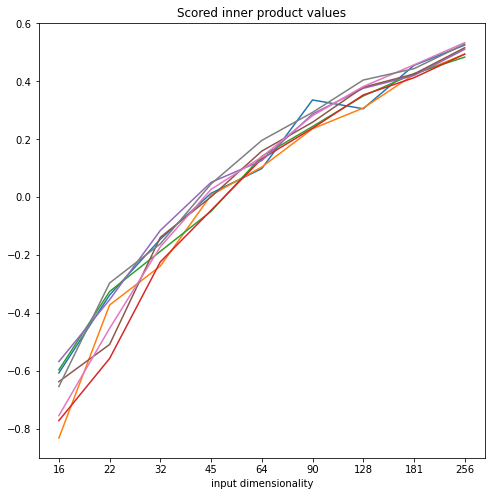

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.plot(np.array(sc_pivot.T))

ax.set_xticks(np.arange(len(sc_pivot.columns)), labels=sc_pivot.columns)
ax.set_xlabel('input dimensionality')
ax.set_title('Scored inner product values')

## Create a scoring table

First goal: avoid component slot "collisions"

Text(0.5, 1.0, 'Mean tolerance margin in inner product probing test for context encoding dimensions')

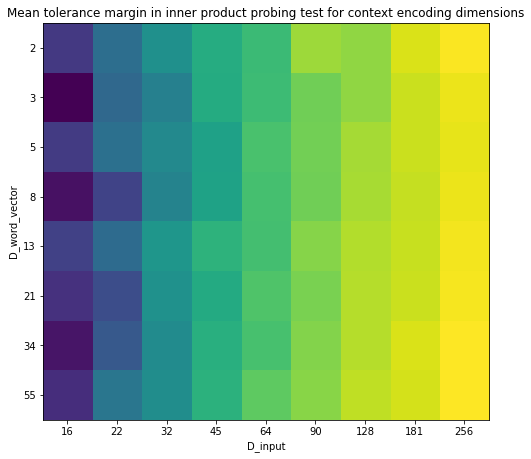

In [19]:


fig, ax = plt.subplots(1,1,figsize=(8,8))
im1 = ax.imshow(np.array(sc_pivot))

ax.set_yticks(np.arange(len(sc_pivot)), labels=sc_pivot.index)
ax.set_xticks(np.arange(len(sc_pivot.columns)), labels=sc_pivot.columns)
ax.set_xlabel('D_input')
ax.set_ylabel('D_word_vector')
ax.set_title('Mean tolerance margin in inner product probing test for context encoding dimensions')



In [20]:
alloc_tbl = []

for D_w in fibs:
    for D_i in cand_D:
        db.set_D_wordvec(D_w)
        db.D_input = D_i 
        
        for t in cand_tokens:
              
            adf,av = db.token_link_matrix(t,1)
            empty_slots = sum(av.sum(axis=0)==0)
            crowd_slots = sum((av != 0).sum(axis=0)>1)
            row = (D_w,D_i,t,empty_slots,crowd_slots)
            alloc_tbl.append(row)
#            print(row)
        
alloc_df = pd.DataFrame(alloc_tbl)
        

-- loaded the skipgram model tank/fasttext_2.model --


-- loaded the skipgram model tank/fasttext_3.model --


-- loaded the skipgram model tank/fasttext_13.model --


-- loaded the skipgram model tank/fasttext_21.model --


-- loaded the skipgram model tank/fasttext_34.model --


-- loaded the skipgram model tank/fasttext_55.model --


## The total score is ...

**efficiency** (ratio of non-empty slots) **x accuracy** (number of non-collided slots)

This will be used for the Contextual Encoding dimension selection

In [21]:
alloc_df = pd.DataFrame(alloc_tbl,columns=['D_w','D_i','token','empty_slots','crowd_slots'])
alloc_df['efficiency'] = 1.0 - (alloc_df.empty_slots / alloc_df.D_i )
alloc_df['accuracy'] = 1.0 - (alloc_df.crowd_slots / alloc_df.D_i )
alloc_df['score'] = alloc_df.efficiency * alloc_df.accuracy

In [11]:
#alloc_df.to_csv('slot_allocation_scores.csv',index=False)
alloc_df = pd.read_csv('slot_allocation_scores.csv')
alloc_df

,D_w,D_i,token,empty_slots,crowd_slots,efficiency,accuracy,score
0,2,16,Afr-0045_170_elephants-11,1,7,0.937500,0.562500,0.527344
1,2,16,Bel-4321_129_cones-6,2,5,0.875000,0.687500,0.601562
2,2,16,Red-a286_103_squirrels-30,7,4,0.562500,0.750000,0.421875
3,2,16,Wat-9861_153_buffaloes-5,2,9,0.875000,0.437500,0.382812
4,2,16,Meg-fd01_213_mammals-3,2,6,0.875000,0.625000,0.546875
...,...,...,...,...,...,...,...,...
1435,55,256,Nor-d13e_197_otters-33,21,171,0.917969,0.332031,0.304794
1436,55,256,Cob-d13e_5_cobras-6,107,46,0.582031,0.820312,0.477448
1437,55,256,Com-2ad3_4_bat-4,55,109,0.785156,0.574219,0.450851
1438,55,256,Hou-905b_116_birds-24,5,236,0.980469,0.078125,0.076599


In [12]:
slot_eff = alloc_df.groupby(['D_w','D_i']).efficiency.mean()
pd.DataFrame(slot_eff).reset_index().pivot(columns='D_i',index='D_w')


efficiency                                                              \
D_i        16        22        32        45        64        90        128   
D_w                                                                          
2     0.715625  0.622727  0.456250  0.375556  0.267969  0.209444  0.147266   
3     0.828125  0.743182  0.600000  0.497778  0.375000  0.293333  0.213281   
5     0.928125  0.877273  0.773438  0.650000  0.536719  0.424444  0.325781   
8     0.987500  0.950000  0.904687  0.816667  0.707812  0.586667  0.471094   
13    1.000000  0.993182  0.971875  0.921111  0.846094  0.742778  0.630859   
21    1.000000  0.995455  0.996875  0.981111  0.934375  0.873889  0.776563   
34    1.000000  0.997727  1.000000  0.994444  0.979688  0.952222  0.905859   
55    1.000000  1.000000  1.000000  1.000000  0.996875  0.987222  0.971094   

                         
D_i       181       256  
D_w                      
2    0.108287  0.077930  
3    0.156630  0.114258  
5    0.242818  0.180664  
8    0.362155  0.276172  
13   0.503867  0.403906  
21   0.645856  0.560156  
34   0.798066  0.725586  
55   0.905249  0.862891

In [13]:

slot_scores = alloc_df.groupby(['D_w','D_i']).score.mean()
df = pd.DataFrame(slot_scores).reset_index().pivot(columns='D_i',index='D_w')
df.columns = df.columns.droplevel(0)
#df.to_csv('slot_dimension_score_table.csv')
df

D_i,16,22,32,45,64,90,128,181,256
D_w,,,,,,,,,
2,0.452930,0.455992,0.375830,0.336173,0.250366,0.201660,0.143661,0.106724,0.077180
3,0.381250,0.412190,0.435937,0.401210,0.333472,0.271981,0.204385,0.152327,0.112324
5,0.218945,0.280372,0.418262,0.422667,0.419800,0.360160,0.297449,0.228574,0.174120
8,0.087695,0.147727,0.279248,0.379457,0.441040,0.431012,0.393097,0.323562,0.258437
13,0.018750,0.048037,0.143164,0.235185,0.350037,0.409049,0.436502,0.399029,0.351505
21,0.006250,0.010537,0.052246,0.108025,0.208582,0.298543,0.379822,0.419168,0.424075
34,0.000000,0.004442,0.014063,0.030790,0.088672,0.159605,0.256436,0.374090,0.420340
55,0.000000,0.000000,0.000000,0.007778,0.024683,0.057494,0.120102,0.254139,0.317675


In [27]:
df.shape

(8, 9)

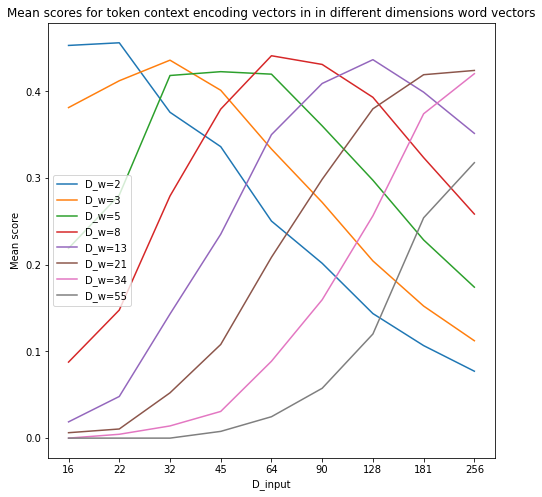

In [32]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(np.array(df.T),label=list("D_w="+pd.Series(df.index).astype(str)))

ax.set_xticks(np.arange(len(df.columns)), labels=df.columns)
ax.set_xlabel('D_input')
ax.set_ylabel('Mean score')
ax.set_title('Mean scores for token context encoding vectors in in different dimensions word vectors')
ax.legend()

In [24]:
curves

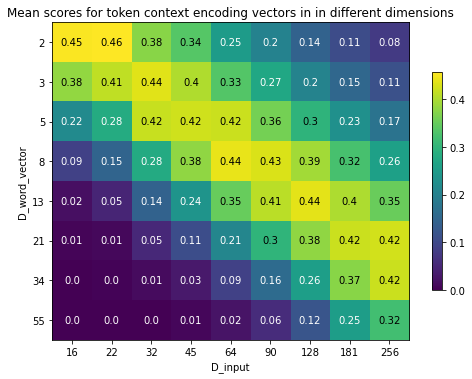

In [43]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
im1 = ax.imshow(df)

ax.set_yticks(np.arange(len(df)), labels=df.index)
ax.set_xticks(np.arange(len(df.columns)), labels=df.columns)
ax.set_xlabel('D_input')
ax.set_ylabel('D_word_vector')
ax.set_title('Mean scores for token context encoding vectors in in different dimensions')
plt.colorbar(im1,shrink=0.5)

for i in range(len(df.index)):
    for j in range(len(df.columns)):
        val =np.array(df.round(2))[i, j]
        text = ax.text(j, i, val,
                       ha="center", va="center", color="w" if val<0.3 else "k")


In [27]:
t_arcs = [db.token_arcs_ex_term(t) for t in list(cand_tokens)+list(db.token_df.index[0:980])]
nlinks = pd.Series([len(t) for t in t_arcs],name='n_linkrows')


print(nlinks)


0      15
1      12
2       7
3      14
4      11
       ..
995     6
996     8
997     9
998     9
999    10
Name: n_linkrows, Length: 1000, dtype: int64


In [28]:
nlinks.describe()

count    1000.000000
mean       10.433000
std         7.049341
min         0.000000
25%         6.000000
50%        10.000000
75%        13.000000
max        50.000000
Name: n_linkrows, dtype: float64

(array([48., 22., 19., 21., 37., 67., 66., 67., 79., 81., 84., 56., 49.,
        47., 38., 22., 23., 14., 13., 19.,  9., 13.,  7.,  7.,  5.,  4.,
         3.,  1.,  2.,  2.,  1.,  1.,  4.,  2.,  1.,  3.,  1.,  1.,  0.,
         1.,  1.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  2.]),
 array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
        33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5, 43.5,
        44.5, 45.5, 46.5, 47.5, 48.5, 49.5, 50.5]),
 <BarContainer object of 50 artists>)

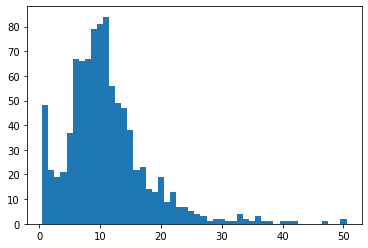

In [29]:
plt.hist(nlinks,bins=np.arange(0.5,51.5,1))